# Three based methods

## Regression Tree
A tree consists of nodes, leaves and branches. At each node a decision is made and two branches branch out of the node. On each level of the tree one predictor X is separated. Therefor for n predictors a n staged tree will build up with n+1 final terminal nodes.

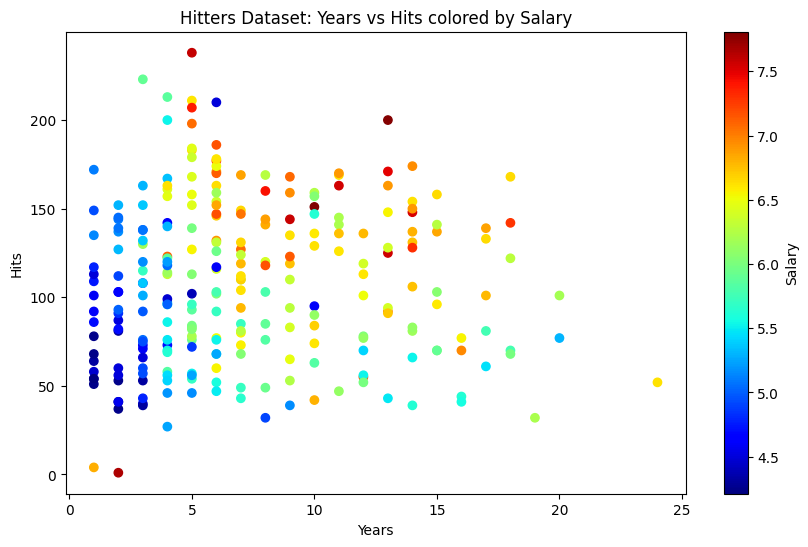

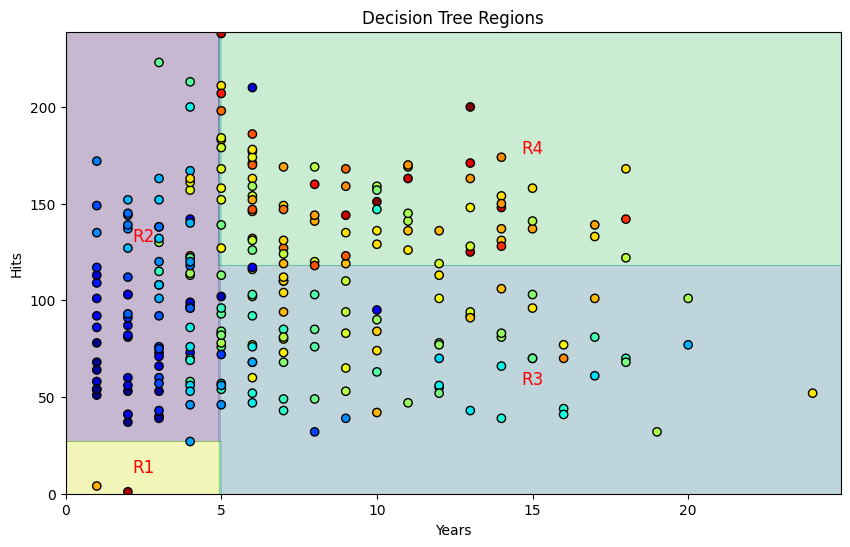

[Years < 5.00]
  [Hits < 27.00]
    Leaf: Predict 7.24
    Leaf: Predict 5.06
  [Hits < 118.00]
    Leaf: Predict 6.00
    Leaf: Predict 6.74


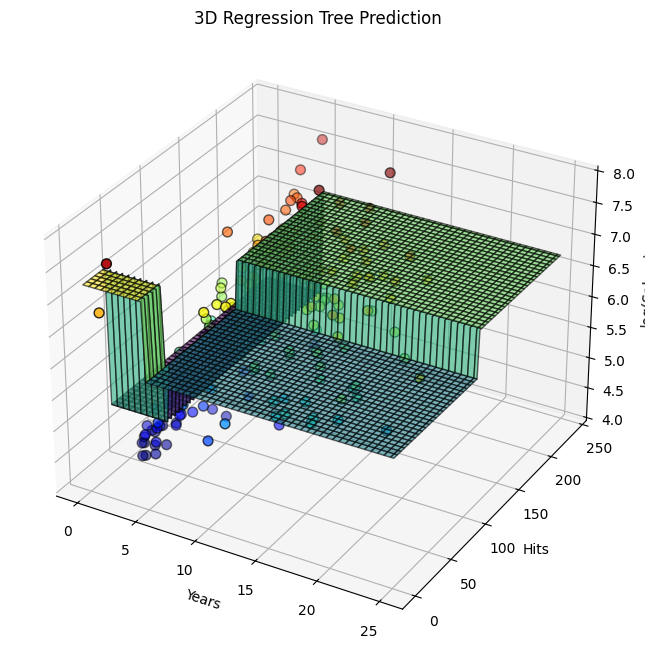

In [21]:
# load the hitters dataset and build a simple tree model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. load the hitters dataset
hitters = pd.read_csv('data/Hitters.csv').dropna()
X1 = hitters[['Years']].values
X2 = hitters[['Hits']].values
y = np.log(hitters['Salary'].values)

# 2. Visualize the data the two predictors and the target as color map jet
plt.figure(figsize=(10, 6))
plt.scatter(X1, X2, c=y, cmap='jet')
plt.colorbar(label='Salary')
plt.xlabel('Years')
plt.ylabel('Hits')
plt.title('Hitters Dataset: Years vs Hits colored by Salary')
plt.show()

# 3. Fit a simple decision tree regressor with max depth 3 from scratch

class TreeNode:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature      # index of the feature to split on
        self.threshold = threshold  # threshold value for the split
        self.left = left            # left child node
        self.right = right          # right child node
        self.value = value          # predicted value for leaf nodes
class DecisionTreeRegressor:
    def __init__(self, max_depth=3, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def fit(self, X, y):
        self.root = self._build_tree(X, y, depth=0)

    def _build_tree(self, X, y, depth):
        n_samples, n_features = X.shape
        if depth >= self.max_depth or n_samples < self.min_samples_split:
            return TreeNode(value=np.mean(y))

        best_feature, best_threshold = self._best_split(X, y, n_features)
        if best_feature is None:
            return TreeNode(value=np.mean(y))

        left_indices = X[:, best_feature] < best_threshold
        right_indices = X[:, best_feature] >= best_threshold

        left_node = self._build_tree(X[left_indices], y[left_indices], depth + 1)
        right_node = self._build_tree(X[right_indices], y[right_indices], depth + 1)

        return TreeNode(feature=best_feature, threshold=best_threshold, left=left_node, right=right_node)

    def _best_split(self, X, y, n_features):
        best_mse = float('inf')
        best_feature, best_threshold = None, None

        for feature in range(n_features):
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_indices = X[:, feature] < threshold
                right_indices = X[:, feature] >= threshold

                if len(y[left_indices]) == 0 or len(y[right_indices]) == 0:
                    continue

                mse = self._calculate_mse(y[left_indices], y[right_indices])
                if mse < best_mse:
                    best_mse = mse
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def _calculate_mse(self, left_y, right_y):
        total_samples = len(left_y) + len(right_y)
        if total_samples == 0:
            return 0
        left_mse = np.var(left_y) * len(left_y) if len(left_y) > 0 else 0
        right_mse = np.var(right_y) * len(right_y) if len(right_y) > 0 else 0
        return (left_mse + right_mse) / total_samples
    
    def predict(self, X):
        return np.array([self._predict_sample(sample, self.root) for sample in X])

    def _predict_sample(self, sample, node):
        if node.value is not None:
            return node.value
        if sample[node.feature] < node.threshold:
            return self._predict_sample(sample, node.left)
        else:
            return self._predict_sample(sample, node.right)
# 4. Train the decision tree regressor
tree = DecisionTreeRegressor(max_depth=2)
tree.fit(X=np.column_stack((X1, X2)), y=y)

def label_leaf_regions(node, bounds, ax, region_id=[1]):
    """
    Recursively label leaf regions.
    
    bounds = [[x0_min, x0_max], [x1_min, x1_max]]
    """
    if node.value is not None:
        # center of region
        x_center = 0.5 * (bounds[0][0] + bounds[0][1])
        y_center = 0.5 * (bounds[1][0] + bounds[1][1])

        ax.text(
            x_center, y_center,
            f"R{region_id[0]}",
            color="red",
            fontsize=12,
            ha="center",
            va="center"
        )
        region_id[0] += 1
        return

    # split feature and threshold
    f = node.feature
    t = node.threshold

    # left child bounds
    left_bounds = [b.copy() for b in bounds]
    left_bounds[f][1] = t

    # right child bounds
    right_bounds = [b.copy() for b in bounds]
    right_bounds[f][0] = t

    label_leaf_regions(node.left, left_bounds, ax, region_id)
    label_leaf_regions(node.right, right_bounds, ax, region_id)


    # Visualize the decision boundaries
def plot_decision_boundaries(tree, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                        np.arange(y_min, y_max, 0.1))
    Z = tree.predict(np.column_stack((xx.ravel(), yy.ravel())))
    Z = Z.reshape(xx.shape)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", cmap="jet")

    initial_bounds = [
        [x_min, x_max],  # Years
        [y_min, y_max]   # Hits
    ]

    label_leaf_regions(tree.root, initial_bounds, ax)

    ax.set_xlabel("Years")
    ax.set_ylabel("Hits")
    ax.set_title("Decision Tree Regions")
    plt.show()

plot_decision_boundaries(tree, np.column_stack((X1, X2)), y)

# Function to print the tree structure
def print_tree(node, feature_names, depth=0):
    indent = "  " * depth
    if node.value is not None:
        print(f"{indent}Leaf: Predict {node.value:.2f}")
        return
    print(f"{indent}[{feature_names[node.feature]} < {node.threshold:.2f}]")
    print_tree(node.left, feature_names, depth + 1)
    print_tree(node.right, feature_names, depth + 1)
# Print the tree structure
feature_names = ['Years', 'Hits']
print_tree(tree.root, feature_names)

from graphviz import Digraph 
# set PATH for graphviz if needed
import os
os.environ["PATH"] += os.pathsep + 'C:/Program Files/Graphviz/bin'

def visualize_tree(root, feature_names):
    dot = Digraph()
    counter = {"id": 0}  # mutable global counter

    def add_node(node):
        node_id = str(counter["id"])
        counter["id"] += 1

        if node.value is not None:
            dot.node(node_id, f"Leaf\nValue = {node.value:.2f}")
            return node_id

        label = f"{feature_names[node.feature]} < {node.threshold:.2f}"
        dot.node(node_id, label)

        left_id = add_node(node.left)
        right_id = add_node(node.right)

        dot.edge(node_id, left_id)
        dot.edge(node_id, right_id)

        return node_id

    add_node(root)
    return dot

# Visualize the tree structure
dot = visualize_tree(tree.root, feature_names)
dot.render('decision_tree', format='png', cleanup=True)


from mpl_toolkits.mplot3d import Axes3D  # für 3D-Plot

def plot_tree_3d(tree, X, y):
    # Feature-Räume
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Meshgrid für Z-Vorhersage
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    # Vorhersage für alle Punkte im Grid
    Z = tree.predict(np.column_stack((xx.ravel(), yy.ravel())))
    Z = Z.reshape(xx.shape)

    # 3D-Figur erstellen
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Oberfläche (predicted Z)
    ax.plot_surface(xx, yy, Z, cmap='viridis', alpha=0.6, edgecolor='k')

    # Scatterplot der Trainingsdaten
    ax.scatter(X[:, 0], X[:, 1], y, c=y, cmap='jet', s=50, edgecolor='k')

    ax.set_xlabel('Years')
    ax.set_ylabel('Hits')
    ax.set_zlabel('log(Salary)')
    ax.set_title('3D Regression Tree Prediction')
    plt.show()

# Aufrufen
plot_tree_3d(tree, np.column_stack((X1, X2)), y)


## Observations on Regression Trees

### Partitioning of the Feature Space
A regression tree partitions the predictor space into \( M \) disjoint regions

$$
\mathcal{R}_1, \mathcal{R}_2, \dots, \mathcal{R}_M
$$

such that each region is an **axis-aligned rectangle**.  
Within each region, the prediction is constant.

The fitted regression function can be written as

$$
\hat{f}(x) = \sum_{m=1}^{M} c_m \, \mathbb{1}(x \in \mathcal{R}_m)
$$

where

$$
c_m = \frac{1}{|\mathcal{R}_m|} \sum_{x_i \in \mathcal{R}_m} y_i
$$

---

### Geometry of Decision Boundaries
Each split in a regression tree has the form

$$
X_j < s
$$

Therefore:
- All splits are **axis-aligned**
- Decision boundaries are **piecewise linear**
- Each region is rectangular

As a result, trees approximate complex shapes (e.g. circles) using many small rectangles.

---

### Comparison with Linear Discriminant Analysis (LDA)
- LDA learns a **single global linear boundary**
- Regression trees learn **multiple local linear boundaries**
- Trees are **nonlinear models**, despite linear split rules

---

### Bias–Variance Tradeoff
- Shallow trees: high bias, low variance  
- Deep trees: low bias, high variance  

A fully grown tree typically overfits without regularization.

---

### Regularization in Trees
Regression trees are regularized by structural constraints:
- Maximum depth
- Minimum samples per leaf
- Minimum impurity decrease
- Cost–complexity pruning

No explicit \( $\ell_1$ \) or \( $\ell_2$ \) penalties are used.

---

## Construction of a Regression Tree

### Objective at Each Split
At each node, choose the split that minimizes the residual sum of squares (RSS):

$$
\text{RSS} =
\sum_{x_i \in \mathcal{R}_1} (y_i - \bar{y}_1)^2
+
\sum_{x_i \in \mathcal{R}_2} (y_i - \bar{y}_2)^2
$$

---

### Greedy Recursive Tree-Building Procedure (Detailed)

**Step 1: Start with all training data at the root node**  
- The root node contains **all observations**.  
- The goal is to partition the predictor space into regions where the target variable has **low variance**.

**Step 2: For each predictor $X_j$ and each candidate split point $s$**  
1. **Candidate split points $s$**:  
   - Use **all unique values** of $X_j$ in the current node as potential thresholds.  
   - Alternatively, for efficiency, you can use **midpoints between consecutive sorted values**.  

2. **Split the data into two regions**:  
$$
\mathcal{R}_1 = \{ x : X_j < s \}, \quad
\mathcal{R}_2 = \{ x : X_j \ge s \}
$$

3. **Compute the RSS (Residual Sum of Squares)** for this split:  
$$
RSS = \sum_{x_i \in \mathcal{R}_1} (y_i - \bar{y}_1)^2
    + \sum_{x_i \in \mathcal{R}_2} (y_i - \bar{y}_2)^2
$$  
- Here, $\bar{y}_1$ and $\bar{y}_2$ are the **mean target values** in $\mathcal{R}_1$ and $\mathcal{R}_2$.

**Step 3: Choose the best split**  
- Among all features $X_j$ and candidate thresholds $s$, select the **feature and threshold** that **minimizes $RSS$**.  
- This is the **greedy choice**: it optimizes the split **locally** at the current node, without looking ahead.

**Step 4: Recursively apply the procedure**  
- Repeat Steps 2–3 for the left and right child nodes.  
- At each child node, consider only the data points that fall into that node’s region.

**Step 5: Stop when a stopping criterion is met**  
- Maximum tree depth reached ($\text{max\_depth}$)  
- Too few observations in a node ($\text{min\_samples\_split}$)  
- Optional: minimal decrease in $RSS$ ($\text{min\_impurity\_decrease}$)  

**Step 6: Assign predictions to terminal nodes (leaves)**  
- Each leaf node predicts the **mean target value** of all training observations that fall into that leaf:  
$$
\hat{y}_{\text{leaf}} = \frac{1}{|\mathcal{R}_m|} \sum_{x_i \in \mathcal{R}_m} y_i
$$  
- The result is a **piecewise constant function** over the feature space.


---

## Prediction with a Regression Tree

Given a new observation  \( x \) :

1. Start at the root node  
2. Apply the split rule  \( $ X_j $ < s \)   
3. Move left or right depending on the condition  
4. Repeat until a terminal node is reached  
5. Predict the mean response of that leaf

Formally,

$$
\hat{y}(x) = c_m \quad \text{such that } x \in \mathcal{R}_m
$$
>A single regression tree predicts for a new observation only the mean target value of the leaf region it falls into; therefore, the prediction is **locally constant** and piecewise-constant over the feature space.

---

## Number of Regions
A tree with \( L \) levels (stages) can have at most

$$
2^L
$$

terminal regions (leaves).

The actual number may be smaller due to early stopping or pruning.

---

## Key Takeaways
- Regression trees partition the feature space into axis-aligned rectangles  
- Predictions are constant within each region  
- Trees are flexible but geometrically constrained  
- Complexity is controlled by depth and pruning  
- Trees form the basis of powerful ensemble methods such as Random Forests and Boosting



## Tree Pruning

A fully grown regression tree can be created by repeatedly splitting nodes until each leaf contains only a single observation. While such a tree is extremely flexible and fits the training data almost perfectly, it tends to **overfit** and generalizes poorly to new data.

**Tree pruning** is a method to reduce the size of a fully grown tree in order to improve generalization. The main idea is:

1. Identify branches and leaves that **contribute little** to reducing the test error (or increase the variance without much gain in bias reduction).
2. Remove or collapse these nodes to form a **smaller subtree**.
3. Choose the **optimal subtree** (usually via cross-validation) that achieves a good trade-off between model complexity and prediction error.

Formally, pruning aims to find a subtree $T \subset T_0$ of the full tree $T_0$ that **minimizes a cost-complexity measure**, for example:

$$
R_\alpha(T) = R(T) + \alpha |T|
$$

- $R(T)$: error of the tree (e.g., RSS for regression)  
- $|T|$: number of terminal nodes (leaves) in the tree  
- $\alpha$: complexity penalty parameter

By increasing $\alpha$, we penalize larger trees more, resulting in a **simpler tree** with fewer leaves that generalizes better.

### Cost-Complexity Pruning Example

Suppose we have a small regression tree with 4 leaves:

| Leaf | Prediction | RSS Contribution |
|------|------------|----------------|
| R1   | 5          | 2              |
| R2   | 8          | 3              |
| R3   | 6          | 1              |
| R4   | 9          | 4              |

- Total RSS: $R(T_0) = 2 + 3 + 1 + 4 = 10$  
- Number of leaves: $|T_0| = 4$

If we prune leaves R3 and R4 (merge them into their parent):

- New RSS: $R(T_1) = 2 + 3 + 6 = 11$  
- New number of leaves: $|T_1| = 3$

Compute cost-complexity measure $R_\alpha(T) = R(T) + \alpha |T|$:

- For $\alpha = 1$:
  $$
  R_\alpha(T_0) = 10 + 1 \cdot 4 = 14, \quad
  R_\alpha(T_1) = 11 + 1 \cdot 3 = 14
  $$
  → tie, simpler tree might be preferred  

- For $\alpha = 2$:
  $$
  R_\alpha(T_0) = 10 + 2 \cdot 4 = 18, \quad
  R_\alpha(T_1) = 11 + 2 \cdot 3 = 17
  $$
  → pruned tree preferred, larger $\alpha$ favors **smaller trees** that generalize better.

> In  cost complexity pruning the pruning goes always bottom up as the highest flexibility is always in the lowest layer of the tree.

### Building a regression tree with pruning
1. Use recursive binary split to construct a full tree T0 on the training data where in the terminal leave each leave holds only a predetermined minimum set train data pair(s) x,y
2. Apply cost complexity pruning to the large tree in order to obtain a sequence of subtrees as a function of $\alpha$
3. Use Cross validation e.g. K fold cross validation to select the best performing subtree 
4. Redo step 1 and 2 on the chosen subtree and $\alpha$
5. Return the subtree for the best $\alpha$ with lowest test error





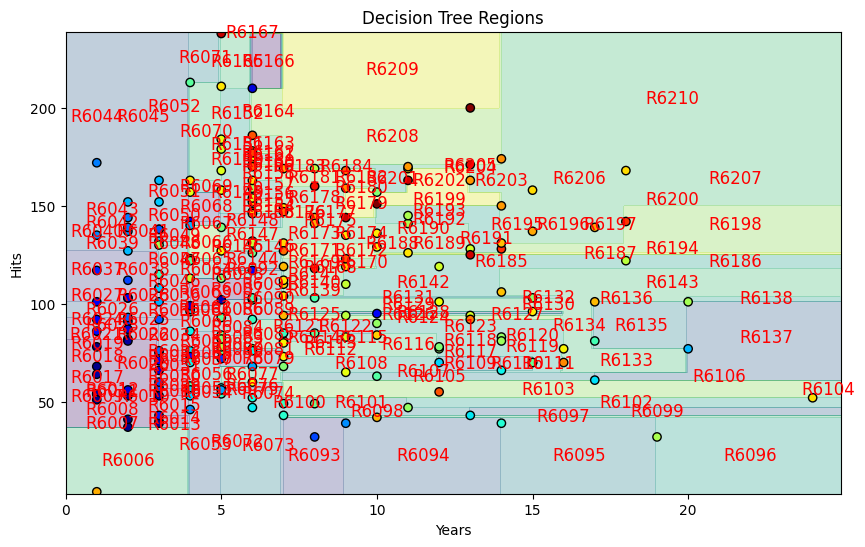

[Years < 5.00]
  [Years < 4.00]
    [Hits < 37.00]
      Leaf: Predict 6.82
      [Hits < 108.00]
        [Hits < 57.00]
          [Years < 3.00]
            [Hits < 56.00]
              [Hits < 54.00]
                [Hits < 51.00]
                  [Hits < 41.00]
                    Leaf: Predict 4.25
                    Leaf: Predict 4.21
                  [Years < 2.00]
                    Leaf: Predict 4.25
                    Leaf: Predict 4.25
                Leaf: Predict 4.27
              Leaf: Predict 4.50
            [Hits < 40.00]
              Leaf: Predict 4.32
              [Hits < 53.00]
                [Hits < 43.00]
                  Leaf: Predict 4.50
                  Leaf: Predict 4.79
                Leaf: Predict 4.32
          [Years < 3.00]
            [Hits < 82.00]
              [Years < 2.00]
                [Hits < 68.00]
                  Leaf: Predict 4.32
                  [Hits < 78.00]
                    Leaf: Predict 4.25
                    Leaf: P

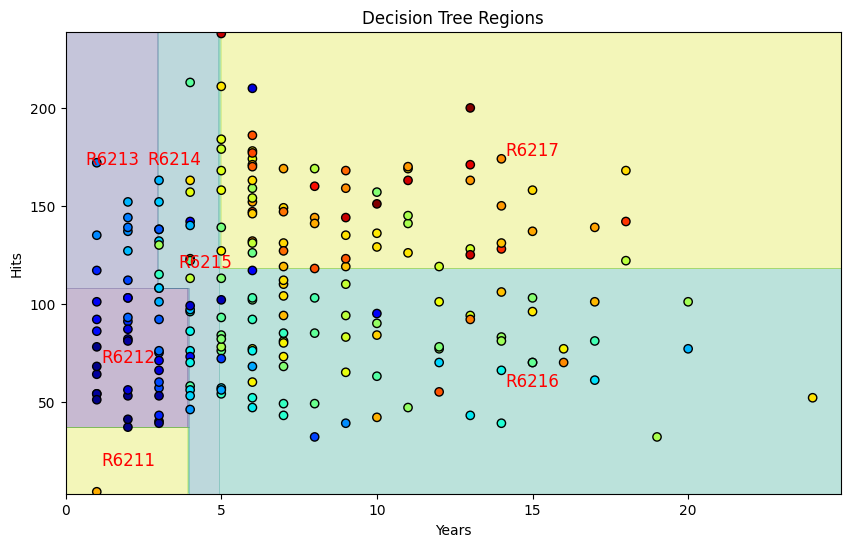

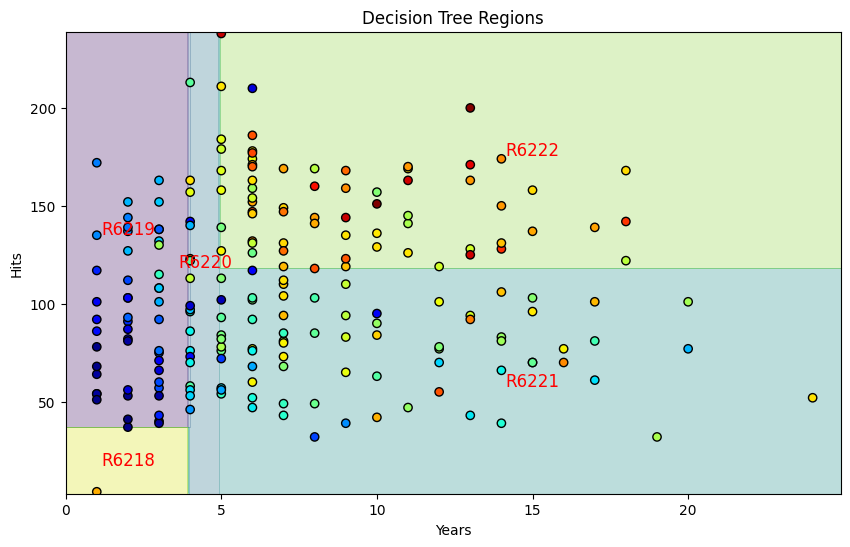

[Years < 5.00]
  [Years < 4.00]
    [Hits < 37.00]
      Leaf: Predict 6.82
      Leaf: Predict 4.84
    Leaf: Predict 5.51
  [Hits < 118.00]
    Leaf: Predict 5.98
    Leaf: Predict 6.63
(210, 5)
(210,)
210


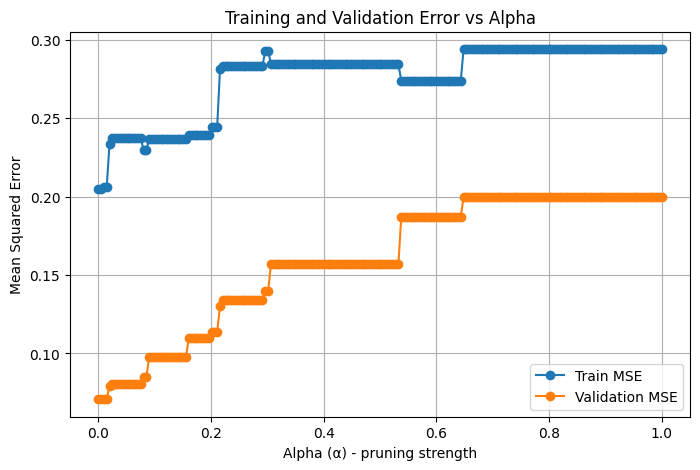

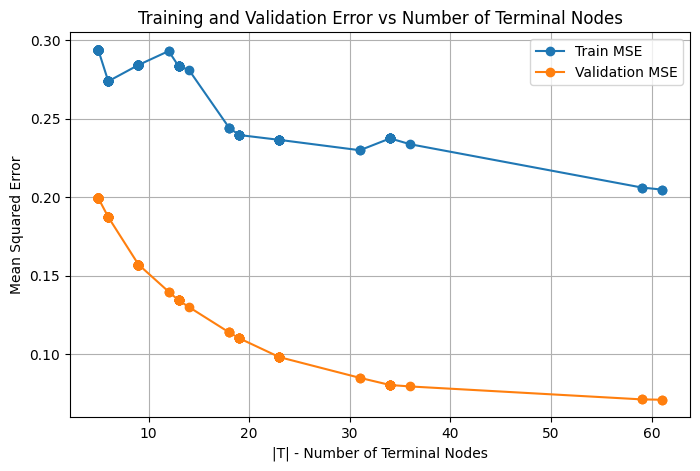

In [49]:
## Now expand the tree class with cost complexity pruning and try it on the hitters dataset

#1. load the hitters dataset
hitters = pd.read_csv('data/Hitters.csv').dropna()
# lets use more features now
X1 = hitters[['Years']].values
X2 = hitters[['Hits']].values
X3 = hitters[['HmRun']].values
X4 = hitters[['Runs']].values
X5 = hitters[['RBI']].values
y = np.log(hitters['Salary'].values)

# split into training and validation set for cross validation pruning
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    np.column_stack((X1, X2, X3, X4, X5)), y, test_size=0.2, random_state=42
)



# copy the tree class and add cost complexity pruning methods to the class
import numpy as np

class TreeNode:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature      # index of feature used for split
        self.threshold = threshold  # threshold value for split
        self.left = left            # left child
        self.right = right          # right child
        self.value = value          # prediction if leaf

class DecisionTreeRegressor:
    def __init__(self, max_depth=1000, min_samples_split=2):
        """
        Fully grown regression tree with optional pruning.

        Parameters:
        - max_depth: maximum depth of the tree (default: very large)
        - min_samples_split: minimum number of samples to allow a split
        """
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    # ----------------- Tree Building -----------------
    def fit(self, X, y):
        """Build a fully grown tree from training data"""
        self.root = self._build_tree(X, y, depth=0)

    def _build_tree(self, X, y, depth):
        n_samples, n_features = X.shape

        # Stop splitting if max depth reached or too few samples
        if depth >= self.max_depth or n_samples < self.min_samples_split:
            return TreeNode(value=np.mean(y))

        # Find best split
        best_feature, best_threshold = self._best_split(X, y, n_features)
        if best_feature is None:
            return TreeNode(value=np.mean(y))

        left_indices = X[:, best_feature] < best_threshold
        right_indices = X[:, best_feature] >= best_threshold

        # Recursively build left and right children
        left_node = self._build_tree(X[left_indices], y[left_indices], depth + 1)
        right_node = self._build_tree(X[right_indices], y[right_indices], depth + 1)

        return TreeNode(feature=best_feature, threshold=best_threshold, left=left_node, right=right_node)

    def _best_split(self, X, y, n_features):
        best_mse = float('inf')
        best_feature, best_threshold = None, None

        for feature in range(n_features):
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_indices = X[:, feature] < threshold
                right_indices = X[:, feature] >= threshold

                # Skip splits creating empty leaves
                if len(y[left_indices]) == 0 or len(y[right_indices]) == 0:
                    continue

                mse = self._calculate_mse(y[left_indices], y[right_indices])
                if mse < best_mse:
                    best_mse = mse
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def _calculate_mse(self, left_y, right_y):
        total_samples = len(left_y) + len(right_y)
        left_mse = np.var(left_y) * len(left_y) if len(left_y) > 0 else 0
        right_mse = np.var(right_y) * len(right_y) if len(right_y) > 0 else 0
        return (left_mse + right_mse) / total_samples

    # ----------------- Prediction -----------------
    def predict(self, X):
        return np.array([self._predict_sample(sample, self.root) for sample in X])

    def _predict_sample(self, sample, node):
        if node.value is not None:
            return node.value
        if sample[node.feature] < node.threshold:
            return self._predict_sample(sample, node.left)
        else:
            return self._predict_sample(sample, node.right)

    # ----------------- Cost-Complexity Pruning -----------------
# ----------------- Cost-Complexity Pruning -----------------
# ----------------- Cost-Complexity Pruning -----------------
    def prune(self, alpha=0.0, X_val=None, y_val=None):
        """
        Bottom-up cost-complexity pruning.

        Definitions:
        - R(T)   : RSS of subtree T on validation data
        - |T|    : number of terminal nodes (leaves) in subtree T
        - α      : complexity penalty
        - R_α(T) = R(T) + α |T|

        Pruning rule:
        Collapse node t if
            R(t) + α <= R(T_t) + α |T_t|
        """

        # -------- Helper: count terminal nodes --------
        def _count_leaves(node):
            if node.value is not None:
                return 1
            return _count_leaves(node.left) + _count_leaves(node.right)

        # -------- Recursive bottom-up pruning --------
        def _prune_node(node, Xv, yv):
            # Leaf: nothing to prune
            if node.value is not None:
                return

            # Route validation data to children
            left_mask = Xv[:, node.feature] < node.threshold
            X_left, y_left = Xv[left_mask], yv[left_mask]
            X_right, y_right = Xv[~left_mask], yv[~left_mask]

            # Prune children first (bottom-up)
            _prune_node(node.left, X_left, y_left)
            _prune_node(node.right, X_right, y_right)

            # If no validation data reaches this node, skip pruning
            if len(yv) == 0:
                return

            # -------- Error of subtree T_t --------
            y_pred_subtree = np.array([
                self._predict_sample(x, node) for x in Xv
            ])
            R_T = np.sum((yv - y_pred_subtree) ** 2)

            # -------- Error if collapsed to a leaf t --------
            c_t = np.mean(yv)
            R_t = np.sum((yv - c_t) ** 2)

            # -------- Tree complexity --------
            T_leaves = _count_leaves(node)

            # -------- Cost-complexity comparison --------
            cost_subtree = R_T + alpha * T_leaves
            cost_collapsed = R_t + alpha

            # -------- Prune if beneficial --------
            if cost_collapsed <= cost_subtree:
                node.left = None
                node.right = None
                node.feature = None
                node.threshold = None
                node.value = c_t

        # Start pruning from the root
        _prune_node(self.root, X_val, y_val)






# 4. Train the decision tree regressor T0
tree = DecisionTreeRegressor(max_depth=1E6)
X_train_reduced = X_train[:, :2]
tree.fit(X=X_train_reduced, y=y_train)
X_val_reduced = X_val[:, :2]


# Visualize the decision boundaries
plot_decision_boundaries(tree, X_train_reduced, y_train)

# 
# Function to print the tree structure
def print_tree(node, feature_names, depth=0):
    indent = "  " * depth
    if node.value is not None:
        print(f"{indent}Leaf: Predict {node.value:.2f}")
        return
    print(f"{indent}[{feature_names[node.feature]} < {node.threshold:.2f}]")
    print_tree(node.left, feature_names, depth + 1)
    print_tree(node.right, feature_names, depth + 1)
# Print the tree structure
feature_names = ['Years', 'Hits', 'HmRun', 'Runs', 'RBI']
print_tree(tree.root, feature_names)

# now we can try to prune the tree based on cost complexity pruning
tree.prune(alpha=0.5, X_val=X_val_reduced, y_val=y_val)

# Plot the pruned tree decision boundaries
plot_decision_boundaries(tree, X_train_reduced, y_train)

# Print the pruned tree structure
#print_tree(tree.root, feature_names)

# now we can try to prune the tree based on cost complexity pruning
tree.prune(alpha=1, X_val=X_val_reduced, y_val=y_val)

# Plot the pruned tree decision boundaries
plot_decision_boundaries(tree, X_train_reduced, y_train)

# Print the pruned tree structure
print_tree(tree.root, feature_names)
def count_leaves(node):
    if node is None:
        return 0
    if node.value is not None:
        return 1
    return count_leaves(node.left) + count_leaves(node.right)



from copy import deepcopy
import matplotlib.pyplot as plt
import numpy as np

# Candidate alpha values
alphas = np.linspace(0, 1, 200)  # 0.0, 0.05, ..., 0.5

train_mse = []
val_mse = []
num_leaves = []
# Fully grown tree
tree_full = DecisionTreeRegressor(max_depth=1E6, min_samples_split=1)
tree_full.fit(X_train, y_train)
print(np.shape(X_train))
print(np.shape(y_train))
print(count_leaves(tree_full.root))

for alpha in alphas:
    # Deep copy the full tree to prune
    tree = deepcopy(tree_full)
    
    # Prune using validation set
    tree.prune(alpha=alpha, X_val=X_val, y_val=y_val)
    # Count number of terminal nodes

    num_leaves.append(count_leaves(tree.root))

    # Predict on training and validation sets
    y_train_pred = tree.predict(X_train)
    y_val_pred = tree.predict(X_val)
    
    # Compute MSE
    train_mse.append(np.mean((y_train - y_train_pred)**2))
    val_mse.append(np.mean((y_val - y_val_pred)**2))

# Plot training and validation error
plt.figure(figsize=(8, 5))
plt.plot(alphas, train_mse, label='Train MSE', marker='o')
plt.plot(alphas, val_mse, label='Validation MSE', marker='o')
plt.xlabel('Alpha (α) - pruning strength')
plt.ylabel('Mean Squared Error')
plt.title('Training and Validation Error vs Alpha')
plt.legend()
plt.grid(True)
plt.show()

# Plot training and validation error for |T| (number of terminal nodes)

plt.figure(figsize=(8, 5))
plt.plot(num_leaves, train_mse, label='Train MSE', marker='o')
plt.plot(num_leaves, val_mse, label='Validation MSE', marker='o')
plt.xlabel('|T| - Number of Terminal Nodes')    
plt.ylabel('Mean Squared Error')
plt.title('Training and Validation Error vs Number of Terminal Nodes')
plt.legend()
plt.grid(True)
plt.show()







## Classification Tree 